<a href="https://colab.research.google.com/github/Anastasia-2002/Concrete-Crack-Detector/blob/main/23_EG_CE_018_L10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset preparation and preprocessing

In [2]:
# Verify Required Libraries
!pip show matplotlib seaborn scikit-learn tensorflow

Name: matplotlib
Version: 3.10.0
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analyze, test, perform and/or display publicly, prepare
 derivative works, distribute, and otherwise use matplotlib
 alone or in any derivative version, provided, however, that MDT's
 License Agreement and MDT's notice of copyright, i.e., "Copyright (c)
 2012- Matplotlib Development Team; All Rights Reserved" are retained in
 matplotlib

In [3]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
accuracy_score, precision_score, recall_score,
f1_score, classification_report, confusion_matrix
)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
print(f'TensorFlow version : {tf.__version__}')
print(f'Random seed set to : {SEED}')

TensorFlow version : 2.20.0
Random seed set to : 42


In [4]:
results_dir = "results/lab7/"
if not os.path.exists(results_dir):
  os.makedirs(results_dir, exist_ok=True)

In [5]:
!nvidia-smi
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  print(f'\nGPUs available: {len(gpus)}')
  for gpu in gpus:
      print(f' - {gpu}')
else:
  print('\nNo GPU found — training will run on CPU (slower).')

Thu Jul 30 12:37:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
# Define the path to your zipped dataset on Google Drive
# IMPORTANT: Update this path to your actual file location
zip_file_path = '/content/drive/MyDrive/archive (1) (1).zip'

# Define the target directory where you want to unzip the dataset
# This will create a new folder in your Colab environment
# IMPORTANT: Update this path to your desired extraction location
extract_dir = './data'

import os

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
print(f'Unzipping {zip_file_path} to {extract_dir}...')
!unzip -q "{zip_file_path}" -d "{extract_dir}"
print('Unzipping complete!')

# List the contents of the extracted directory to verify
print(f'Contents of {extract_dir}:')
!ls -F "{extract_dir}"


Unzipping /content/drive/MyDrive/archive (1) (1).zip to ./data...
Unzipping complete!
Contents of ./data:
Decks/	Pavements/  Walls/


In [7]:
import os
import shutil
from pathlib import Path

# Updated base_input to point to the directory where the zip file was unzipped
base_input = "/content/drive/MyDrive/extracted_dataset/"

# Define the base output directory for renamed files, also in Google Drive
# You can change 'PlantVillage_Dataset_Renamed' to another name if preferred
base_output = "/content/drive/MyDrive/concrete crack renamed/"

# Ensure the base_output directory exists
os.makedirs(base_output, exist_ok=True)

base_path = Path(base_output)
print(f"Base input path: {base_input}")
print(f"Base output path: {base_output}")
base_path

Base input path: /content/drive/MyDrive/extracted_dataset/
Base output path: /content/drive/MyDrive/concrete crack renamed/


PosixPath('/content/drive/MyDrive/concrete crack renamed')

In [8]:
import random
import os
import shutil

# Define the desired splits for the output dataset and their ratios
splits_config = {
    "train": 0.7,
    "val": 0.15,
    "test": 0.15
} # Ensure these sum up to 1 (or close to 1 due to integer division)

# Correct the base_input path based on where the dataset was unzipped
base_input = "./data"

print(f"Processing dataset from: {base_input}")
print(f"Outputting to: {base_output}")

# Ensure the base output split directories exist
for split_name in splits_config.keys():
    os.makedirs(os.path.join(base_output, split_name), exist_ok=True)

# Iterate through top-level categories (e.g., Decks, Pavements, Walls)
for category_name in os.listdir(base_input):
    category_path = os.path.join(base_input, category_name)
    if not os.path.isdir(category_path):
        print(f"Skipping non-directory item in base_input: {category_path}")
        continue

    # Iterate through class folders within each category (e.g., healthy, rust)
    for class_folder_name in os.listdir(category_path):
        class_folder_path = os.path.join(category_path, class_folder_name)
        if not os.path.isdir(class_folder_path):
            print(f"Skipping non-directory item in category_path: {class_folder_path}")
            continue

        # Create the combined class label for the output
        final_class_label = f"{category_name}_{class_folder_name}"

        # Get all image files in the current class_folder_path
        all_files = [f for f in os.listdir(class_folder_path) if os.path.isfile(os.path.join(class_folder_path, f))]
        if not all_files:
            print(f"  No files found in {class_folder_path}. Skipping this class.")
            continue

        print(f"  Processing class: {final_class_label} with {len(all_files)} files")

        # Shuffle files for random splitting
        random.shuffle(all_files)

        # Calculate split sizes
        num_total = len(all_files)
        num_train = int(num_total * splits_config["train"])
        num_val = int(num_total * splits_config["val"])
        num_test = num_total - num_train - num_val # Remaining files go to test to ensure all are used

        # Assign files to splits
        train_files = all_files[:num_train]
        val_files = all_files[num_train : num_train + num_val]
        test_files = all_files[num_train + num_val :]

        file_assignments = {
            "train": train_files,
            "val": val_files,
            "test": test_files
        }

        # Copy files to their respective destination directories
        for split_name, files_to_copy in file_assignments.items():
            dst_dir = os.path.join(base_output, split_name, final_class_label)
            os.makedirs(dst_dir, exist_ok=True)

            for file_name in files_to_copy:
                src_file = os.path.join(class_folder_path, file_name)
                shutil.copy(src_file, os.path.join(dst_dir, file_name))

print("Data reorganization complete!")

Processing dataset from: ./data
Outputting to: /content/drive/MyDrive/concrete crack renamed/
  Processing class: Walls_Non-cracked with 14287 files
  Processing class: Walls_Cracked with 3851 files
  Processing class: Decks_Non-cracked with 11595 files
  Processing class: Decks_Cracked with 2025 files
  Processing class: Pavements_Non-cracked with 21726 files
  Processing class: Pavements_Cracked with 2608 files
Data reorganization complete!


In [9]:
BASE_DIR = Path(base_output)
train_dir = BASE_DIR / 'train'
val_dir = BASE_DIR / 'val'
test_dir = BASE_DIR / 'test'


In [10]:
for split, d in [('train', train_dir), ('val', val_dir), ('test',
    test_dir)]:
    exists = d.exists()
    count = sum(1 for _ in d.rglob('*.jpg')) + sum(1 for _ in
    d.rglob('*.png')) if exists else 0
    print(f'{split:>5} dir exists={exists} images≈{count}')

train dir exists=True images≈39261
  val dir exists=True images≈8411
 test dir exists=True images≈8420


In [11]:
IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
BATCH_SIZE = 64
EPOCHS = 50 # EarlyStopping will stop earlier when converged
LR = 1e-3 # Initial learning rate for the CNN from scratch
print(f'Image size : {IMAGE_HEIGHT} x {IMAGE_WIDTH}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Max epochs : {EPOCHS}')
print(f'Learning rate: {LR}')

Image size : 128 x 128
Batch size : 64
Max epochs : 50
Learning rate: 0.001


In [12]:
import tensorflow as tf
from pathlib import Path

# train_dir, val_dir, test_dir are defined in cell CCayiU73ZMeH
# IMAGE_HEIGHT, IMAGE_WIDTH, BATCH_SIZE are defined in cell HCJG9o_VoAUh
# SEED is globally set to 42 in cell 0io_1KkdlHdM

# Re-defining BASE_DIR and split directories to ensure correct paths are used
# in case of kernel state inconsistencies, using the globally defined base_output.
BASE_DIR = Path(base_output)
train_dir = BASE_DIR / 'train'
val_dir = BASE_DIR / 'val'
test_dir = BASE_DIR / 'test'

print(f"Using train_dir: {train_dir}")
print(f"Using val_dir: {val_dir}")
print(f"Using test_dir: {test_dir}")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    str(train_dir), # Convert Path object to string
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    str(val_dir), # Convert Path object to string
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False # Typically no need to shuffle validation data
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    str(test_dir), # Convert Path object to string
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False # Typically no need to shuffle test data
)

Using train_dir: /content/drive/MyDrive/concrete crack renamed/train
Using val_dir: /content/drive/MyDrive/concrete crack renamed/val
Using test_dir: /content/drive/MyDrive/concrete crack renamed/test
Found 39261 files belonging to 6 classes.
Found 8411 files belonging to 6 classes.
Found 8420 files belonging to 6 classes.


In [13]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
  val_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
  batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
)

Found 8411 files belonging to 6 classes.


In [14]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
batch_size=BATCH_SIZE, seed=SEED,shuffle=False,
)

Found 8420 files belonging to 6 classes.


In [15]:
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')

Classes (6): ['Decks_Cracked', 'Decks_Non-cracked', 'Pavements_Cracked', 'Pavements_Non-cracked', 'Walls_Cracked', 'Walls_Non-cracked']


In [16]:
# Capture one fixed batch so the visualisation is stable across re-runs
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

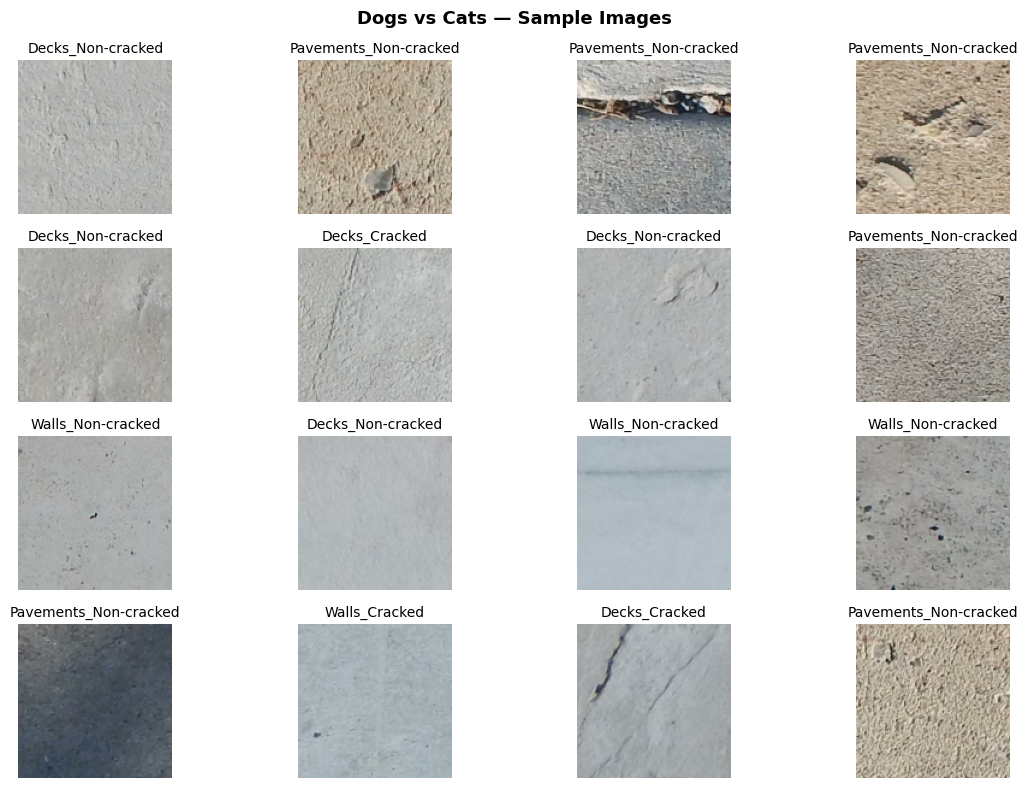

In [17]:
plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    plt.title(class_names[fixed_labels[i]], fontsize=10)
    plt.axis('off')
plt.suptitle('Dogs vs Cats — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lab8_samples.png', dpi=120, bbox_inches='tight')
plt.show()

In [18]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = (
train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE))
val_dataset = (val_dataset.cache().prefetch(buffer_size=AUTOTUNE))
test_dataset = (test_dataset.cache().prefetch(buffer_size=AUTOTUNE))
print('Pipeline optimised with cache + shuffle + prefetch.')

Pipeline optimised with cache + shuffle + prefetch.


In [19]:
data_augmentation = tf.keras.Sequential([
tf.keras.layers.RandomFlip('horizontal'),
tf.keras.layers.RandomRotation(0.2),
tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')

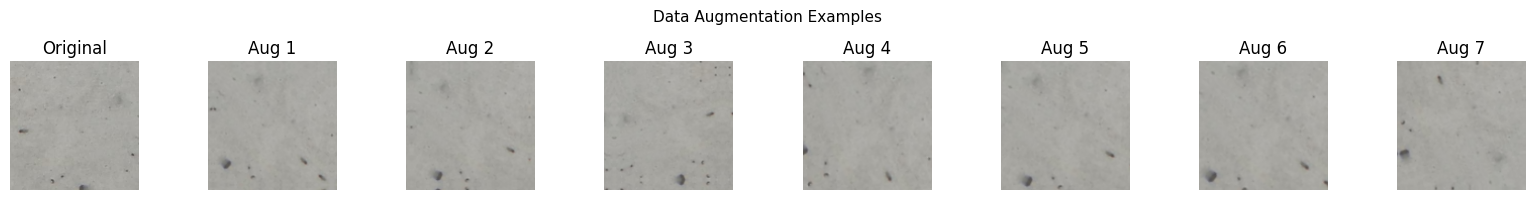

In [20]:
for images, _ in train_dataset.take(1):
    sample = images[0:1] # shape (1, 224, 224, 3)
    break
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original'); axes[0].axis('off')
for i in range(1, 8):
    aug_img = data_augmentation(sample,
                              training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')
plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.savefig('lab8_augmentation.png', dpi=120, bbox_inches='tight')
plt.show()

In [21]:
os.makedirs('models', exist_ok=True)

def make_callbacks(name):
    """Return a fresh set of callbacks for each model."""
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'models/{name}_best.keras',
            monitor='val_accuracy', save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=4, min_lr=1e-7, verbose=1,
        ),
    ]

def plot_learning_curves(history, title='Learning Curves'):
    """Plot accuracy and loss curves side-by-side."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2,
             linestyle='--')
    plt.legend()
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2,
             linestyle='--')
    plt.legend()
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(results_dir + f'lab8_{title.lower().replace(" ",
    "_")}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

def evaluate_model(model, dataset, class_names, title='Model',
                   results_dir='./'):
    """Evaluate a multiclass classification model."""
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        # multiclass prediction (softmax -> argmax)
        preds = np.argmax(probs, axis=1)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    print(f"\n{title}")
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred,
                                         average="weighted"):.4f}')
    print(f'Recall : {recall_score(y_true, y_pred,
                                  average="weighted"):.4f}')
    print(f'F1-Score : {f1_score(y_true, y_pred, average="weighted"):.4f}')
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names,
                                digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(15, 12))
    sns.heatmap(
        cm, cmap='Blues', cbar=False, annot=True, fmt='',
        xticklabels=class_names, yticklabels=class_names,
        annot_kws={'fontsize': 9, 'fontweight': 'bold'}
    )
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(
        results_dir + f'lab8_{title.lower().replace(" ",
        "_")}_confusion.png',
        dpi=120,
        bbox_inches='tight'
    )
    plt.show()
    return accuracy_score(y_true, y_pred)

print('Callbacks and utility functions defined.')

Callbacks and utility functions defined.
